In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [58]:
import matplotlib.pyplot as plt

def plot_multiple(dfs, field, x_axis, legend, xlabel, ylabel, title):
    """
    Plots average SOC (Sum of Costs) vs Opti_Deadline for Bool_Opti=True and Bool_Opti=False
    across multiple CSV files, including scatterplots to show variation.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames containing the data.
        field (str): The field to be plotted on the y-axis.
        x_axis (str): The field to be plotted on the x-axis.
        legend (list of str): Legend labels for each dataset.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        title (str): Title of the plot.

    Returns:
        fig, ax: Matplotlib Figure and Axes objects for further modification.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    for df in dfs:
        # Normalize the specified field
        columns = df.columns.to_list()
        df[field] = df[field] / df[columns[columns.index(field) + 1]]

        # Group by the x_axis and calculate mean
        avg_true = df.groupby(x_axis)[field].mean()

        # Plot the average lines for each DataFrame
        ax.plot(
            avg_true.index, avg_true.values,
            marker="o", linestyle="-"
        )

    # Add labels, title, legend, and grid
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.7)

    # Return the figure and axis for further customization
    return fig, ax


In [59]:
# Path to the CSV file den520d
# csv_file_path1 = "outputs/skipping logic/lacam_den520d_agentsweep.csv"      #lacam + anytime pibt
# csv_file_path2 = "outputs/weighted deadlines/lacam_den520d_agentsweep_wd.csv"  #lacam + anytime pibt (weighted deadline per group size)
# csv_file_path3 = "outputs/pibt_r2/pibt_den520d_agentsweep.csv"  #vanilla v/s anytime pibt
# csv_file_path4 = "outputs/lacam2_run2/lacam_den20d_agentsweep_woskip.csv"  #lacam2

# 323220
# csv_file_path1 = "outputs/skipping logic/lacam_323220_agentsweep_wskip.csv"      #lacam + anytime pibt
# csv_file_path2 = "outputs/weighted deadlines/lacam_323220_agentsweep_wd.csv"  #lacam + anytime pibt (weighted deadline per group size)
# csv_file_path3 = "outputs/pibt_r2/pibt_323220_agentsweep.csv"  #vanilla v/s anytime pibt
# csv_file_path4 = "outputs/lacam2_run2/lacam_323220_agentsweep_woskip.csv"  #lacam2

# htc
# csv_file_path1 = "outputs/skipping logic/lacam_htchantry_agentsweep_wskip.csv"      #lacam + anytime pibt
# csv_file_path2 = "outputs/weighted deadlines/lacam_htchantry_agentsweep_wd.csv"  #lacam + anytime pibt (weighted deadline per group size)
# csv_file_path3 = "outputs/pibt_r2/pibt_htchantry_agentsweep.csv"  #vanilla v/s anytime pibt
# csv_file_path4 = "outputs/lacam2_run2/lacam_htchantry_agentsweep_woskip.csv"  #lacam2

# warehouse
csv_file_path1 = "outputs/skipping logic/lacam_htchantry_agentsweep_wskip.csv"      #lacam + anytime pibt
csv_file_path2 = "outputs/weighted deadlines/lacam_warehouse1_wd.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path3 = "outputs/pibt_r2/pibt_warehouse1_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path4 = "outputs/lacam2_run2/lacam_warehouse1_agentsweep_woskip.csv"  #lacam2


# Plot sum of costs vs opti_deadline with variation
# plot_makespan(csv_file_path1, "soc", "Opti_Deadline")

In [60]:
# Read the CSV file into a DataFrame  #lacam + anytime pibt  (df1["Opti_Deadline"] == 1000)  & 
# df1 = pd.read_csv(csv_file_path1)
# df1 = df1[(df1["agents"] == 260)]
# # Separate data for Bool_Opti=True and Bool_Opti=False
# df_true1 = df1[df1["Bool_Opti"] == True]
# df_false1 = df1[df1["Bool_Opti"] == False]

# weighted deadlines
df2 = pd.read_csv(csv_file_path2)
df2 = df2[df2["agents"] == 180]
# Separate data for Bool_Opti=True and Bool_Opti=False  & (df2["agents"] <= 400)
df_true2 = df2[df2["Bool_Opti"] == True]
df_false2 = df2[df2["Bool_Opti"] == False]

# first we want lacam*, objective 2 not selected, no optimization (df4["Opti_Deadline"] == 1000) & 
# & (df4["functype"] == "")
df4 = pd.read_csv(csv_file_path4)
df4 = df4[(df4["agents"] == 180)]
df4_vanlacstar = df4[(df4["opti_objective"] == False) & (df4["Bool_Opti"] == False) & (df4["functype"] != "opti")]
df4_vanlsobj2 = df4[(df4["opti_objective"] == True) & (df4["Bool_Opti"] == False) & (df4["functype"] != "opti")]
df4_lacstanytime = df4[(df4["opti_objective"] == False) & (df4["Bool_Opti"] == True) & (df4["functype"] == "opti")]
df4_lacstaobj2 = df4[(df4["opti_objective"] == True) & (df4["Bool_Opti"] == True) & (df4["functype"] == "opti")]

# pibt v/s van pibt
df3 = pd.read_csv(csv_file_path3)
df3 = df3[(df3["agents"] == 180) & (df3["solved"] == 1)]
df3_vanpibt = df3[df3["solver"] == "PIBTOLD"]
df3_optpibt = df3[df3["solver"] == "PIBT"]

legend = ["Lacam + Anytime PIBT", "Lacam + Vanilla PIBT",
"Lacam* + Anytime PIBT", "Lacam* + Anytime PIBT + Objective=2", "Vanilla Lacam*", "Vanilla Lacam* + Objective=2 (sum_of_loss minimization)"]
# "Lacam + Vanilla PIBT2", "Lacam + Anytime PIBT (Weighted Deadline)", df_true2, df_false2
# 

# "Sum of Loss/Sum of Loss (LB)", "Summed Loss/Summed Loss(LB) vs num_agents Across Multiple solvers (1000ms Opt-Timeout)")
# "SOC/SOC_LB", "SOC/SOC_LB v/s Num Agents"
# "makespan/makespan_lb", "makespan/makespan_lb v/s Num Agents (1000ms Opt-Timeout)", 
# "Sum of Loss/Sum of Loss (LB)", "Sum of Loss/Sum of Loss (LB) v/s Opti-Deadline")
# df4_vanlacstar, df4_vanlsobj2, df4_lacstanytime, df4_lacstaobj2
# df4_vanlacstar, df4_vanlsobj2, df3_vanpibt, df3_optpibt, "Vanilla PIBT", "Anytime-PIBT", 

# field = "soc"

# fig, ax = plot_multiple([df_true2, df_false2, df4_lacstanytime, df4_lacstaobj2], 
#             field, "Opti_Deadline", legend, "Anytime PIBT Timeout (ms)", "SOC/SOC_LB", "SOC/SOC_LB v/s Opti-Deadline")

# columns = df4_vanlacstar.columns.to_list()
# df4_vanlacstar[field] = df4_vanlacstar[field] / df4_vanlacstar[columns[columns.index(field) + 1]]
# vanlac_mean = df4_vanlacstar.groupby("Opti_Deadline")[field].mean()
# ax.plot(
#     [0, 1, 10, 100, 1000], np.array([vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean]),
#     marker="o", linestyle="-"
# )

# columns = df4_vanlsobj2.columns.to_list()
# df4_vanlsobj2[field] = df4_vanlsobj2[field] / df4_vanlsobj2[columns[columns.index(field) + 1]]
# vanlac_mean = df4_vanlsobj2.groupby("Opti_Deadline")[field].mean()
# ax.plot(
#     [0, 1, 10, 100, 1000], np.array([vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean]),
#     marker="o", linestyle="-"
# )

# ax.legend(legend)


/tmp/ipykernel_1909222/1665812118.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[field] = df[field] / df[columns[columns.index(field) + 1]]
/tmp/ipykernel_1909222/1665812118.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4_vanlacstar[field] = df4_vanlacstar[field] / df4_vanlacstar[columns[columns.index(field) + 1]]
/tmp/ipykernel_1909222/1665812118.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

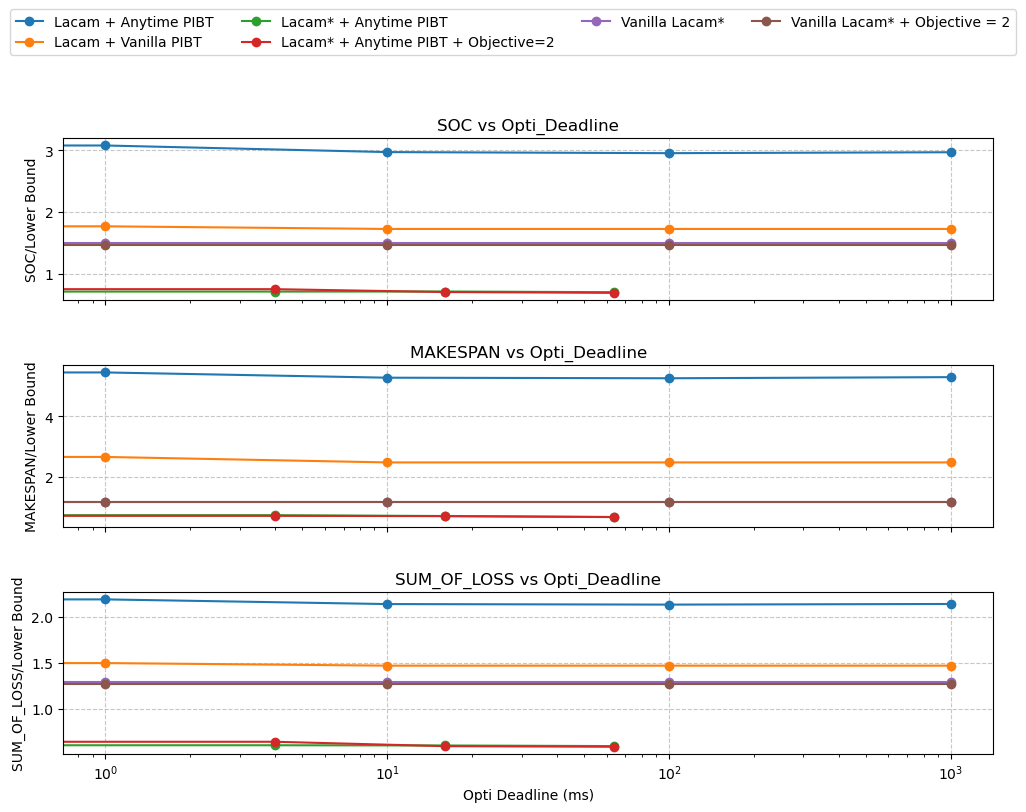

In [57]:
# List of fields to iterate through
fields = ["soc", "makespan", "sum_of_loss"]

# Create a figure and subplots
fig, axes = plt.subplots(len(fields), 1, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.4)  # Adjust vertical spacing between subplots

for idx, field in enumerate(fields):
    ax = axes[idx]
    ax.set_title(f"{field.upper()} vs Opti_Deadline")
    
    # Plot data for each DataFrame in the list
    dfs = [df_true2, df_false2, df4_lacstanytime, df4_lacstaobj2]
    for df, legend_label in zip(dfs, legend):
        columns = df.columns.to_list()
        df[field] = df[field] / df[columns[columns.index(field) + 1]]
        avg_true = df.groupby("Opti_Deadline")[field].mean()
        ax.plot(
            avg_true.index, avg_true.values,
            marker="o", linestyle="-", label=legend_label
        )
    
    # Add additional plots (e.g., for vanlac_mean)
    columns = df4_vanlacstar.columns.to_list()
    df4_vanlacstar[field] = df4_vanlacstar[field] / df4_vanlacstar[columns[columns.index(field) + 1]]
    vanlac_mean = df4_vanlacstar.groupby("Opti_Deadline")[field].mean()
    ax.plot(
        [0, 1, 10, 100, 1000], np.array([vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean]),
        marker="o", linestyle="-", label="Vanilla Lacam*"
    )

    columns = df4_vanlsobj2.columns.to_list()
    df4_vanlsobj2[field] = df4_vanlsobj2[field] / df4_vanlsobj2[columns[columns.index(field) + 1]]
    vanls_mean = df4_vanlsobj2.groupby("Opti_Deadline")[field].mean()
    ax.plot(
        [0, 1, 10, 100, 1000], np.array([vanls_mean, vanls_mean, vanls_mean, vanls_mean, vanls_mean]),
        marker="o", linestyle="-", label="Vanilla Lacam* + Objective = 2"
    )
    
    # Add axis labels
    ax.set_ylabel(f"{field.upper()}/Lower Bound")
    ax.set_xscale("log")
    ax.grid(True, linestyle="--", alpha=0.7)

# Add x-axis label to the last subplot
axes[-1].set_xlabel("Opti Deadline (ms)")
ax.set_xscale('symlog')


# Create a common legend outside the subplots
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))

# Save and show the plot
plt.savefig("multi_field_plot.png", dpi=300, bbox_inches="tight")
plt.show()


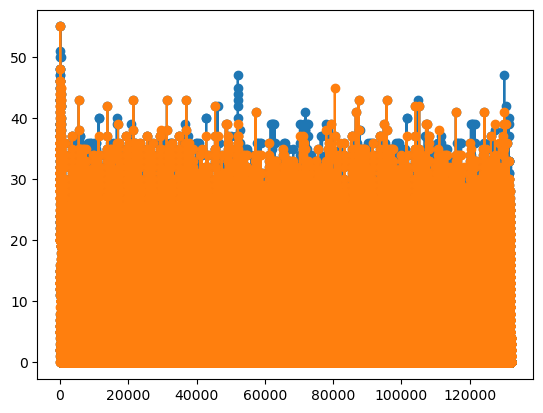

In [49]:
scen_csv = "outputs/scens/lacam_den20d17_agentsweep.csv"
df = pd.read_csv(scen_csv)
df = df[df["Opti_Deadline"]==0]
# , 1, 10, 100, 1000
for i in [0]:
    for j in [1,2]:
        df = df[df[f"Cost_{j}_{i}"].notna()].reset_index(drop=True)
        # Plot the average lines for each CSV file
        plt.plot(
            df.index, df[f"Cost_{j}_{i}"],
            marker="o", linestyle="-"
        )

plt.savefig("costplot.png", dpi=300, bbox_inches="tight")
